In [1]:
# Step 1: Load libraries and dataset

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('titanic_cleaned.csv')
numeric_cols = ['age', 'fare', 'sibsp', 'parch', 'pclass', 'survived']
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True


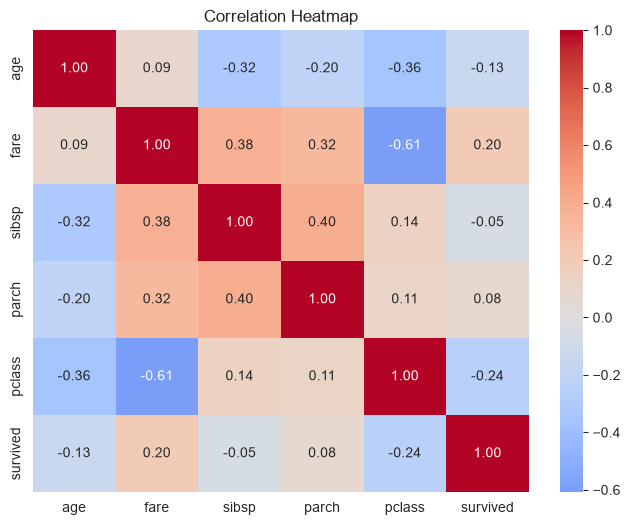

In [2]:
# Step 2: Correlation heatmap

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

sex
male      443
female    230
Name: count, dtype: int64


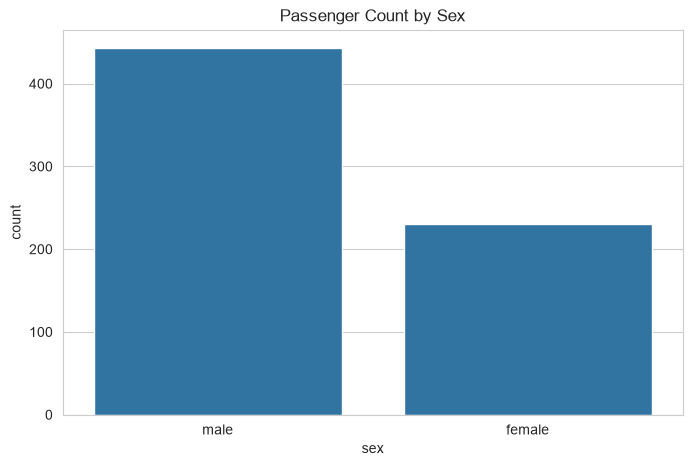

In [3]:
# Step 3: Categorical value counts — sex

print(df['sex'].value_counts())
sns.countplot(x='sex', data=df)
plt.title('Passenger Count by Sex')
plt.show()

class
Third     401
Second    159
First     113
Name: count, dtype: int64


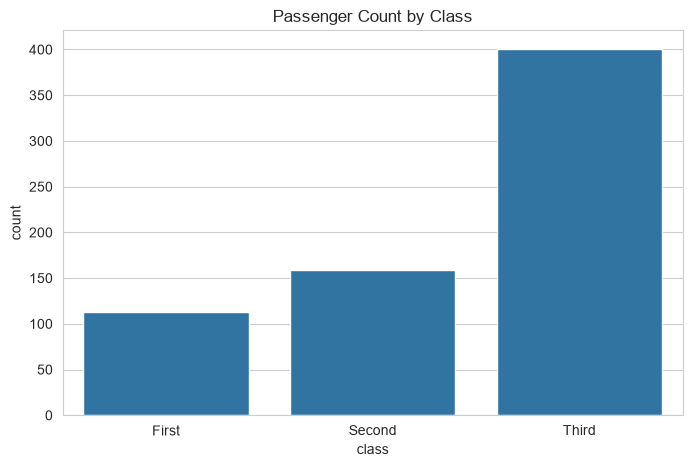

In [4]:
# Step 4: Categorical value counts — class

print(df['class'].value_counts())
sns.countplot(x='class', data=df, order=['First', 'Second', 'Third'])
plt.title('Passenger Count by Class')
plt.show()

embarked
S    511
C    106
Q     56
Name: count, dtype: int64


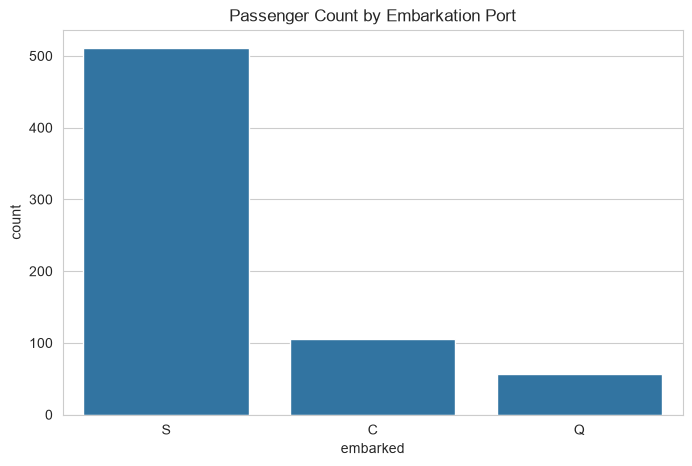

In [5]:
# Step 5: Categorical value counts — embarked

print(df['embarked'].value_counts())
sns.countplot(x='embarked', data=df)
plt.title('Passenger Count by Embarkation Port')
plt.show()

In [6]:
# Step 6: Cross-tab — Class vs Sex (stacked count)

cross_tab = pd.crosstab(df['class'], df['sex'])
cross_tab


sex,female,male
class,,
First,31,82
Second,72,87
Third,127,274


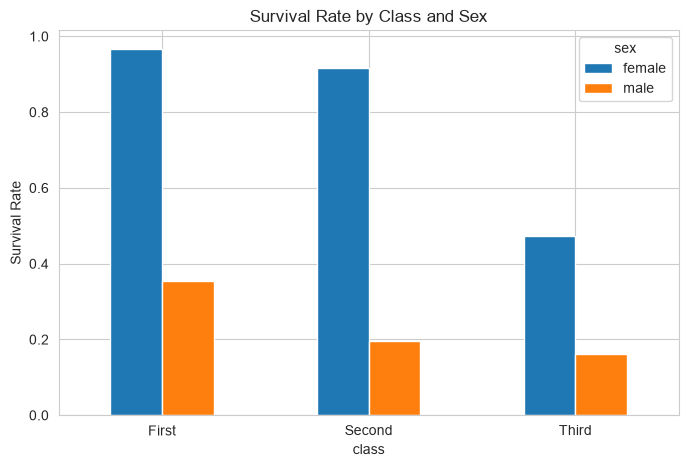

In [7]:
# Step 7: Bar plot — Survival rate by class and sex
# Combines two categorical columns against the numeric survival rate — deeper than Day 1's single-column groupby.

survival_by_class_sex = df.groupby(['class', 'sex'])['survived'].mean().unstack()
survival_by_class_sex

survival_by_class_sex.plot(kind='bar', figsize=(8,5))
plt.title('Survival Rate by Class and Sex')
plt.ylabel('Survival Rate')
plt.xticks(rotation=0)
plt.show()

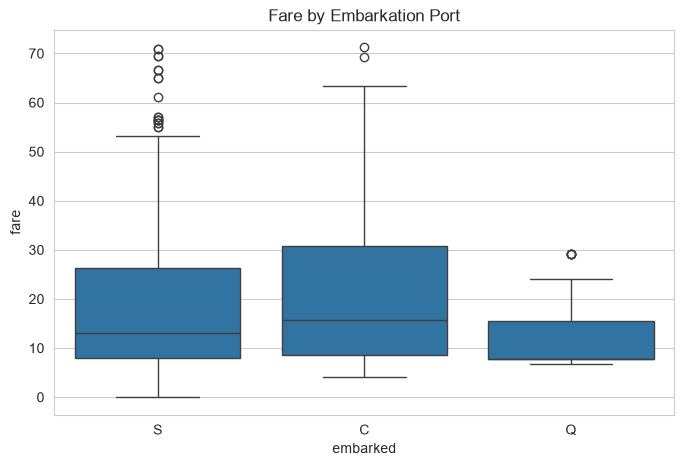

In [8]:
# Step 8: Box plot — Fare by embarkation port
# Cross a categorical column against a numeric one to check if boarding port relates to ticket price.


sns.boxplot(x='embarked', y='fare', data=df)
plt.title('Fare by Embarkation Port')
plt.show()